In [2]:
import os, re, json, pickle, requests
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
 
from PIL import Image
from collections import Counter
from nltk.tokenize import word_tokenize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, accuracy_score,
    precision_score, recall_score, f1_score
)
 
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

/opt/anaconda3/envs/crisisenv/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


True

In [3]:
train_path = "/Users/ananyagupta/CrisisMMD_v2.0/crisismmd_datasplit_all/task_informative_text_img_train.tsv"
dev_path   = "/Users/ananyagupta/CrisisMMD_v2.0/crisismmd_datasplit_all/task_informative_text_img_dev.tsv"
test_path  = "/Users/ananyagupta/CrisisMMD_v2.0/crisismmd_datasplit_all/task_informative_text_img_test.tsv"
image_folder = "/Users/ananyagupta/CrisisMMD_v2.0/data_image"

In [4]:
MAX_LEN    = 40
EMBED_DIM  = 100
HIDDEN_DIM = 192
BATCH_SIZE = 16
EPOCHS     = 20
IMG_SIZE   = 224

In [5]:
def load_data(path):
    df = pd.read_csv(path, sep="\t")
    df = df[['tweet_text', 'image', 'label']]
    df['label'] = df['label'].map({'informative': 1, 'not_informative': 0})
    df = df.dropna(subset=['label'])
    return df
 
train_df = load_data(train_path).sample(n=420, random_state=42)
dev_df   = load_data(dev_path).sample(n=40,  random_state=42)
test_df  = load_data(test_path).sample(n=40,  random_state=42)

In [6]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text
 
def preprocess(text):
    return word_tokenize(clean_text(text))
 
for df in [train_df, dev_df, test_df]:
    df['tokens'] = df['tweet_text'].apply(preprocess)

In [7]:
vocab = Counter([w for row in train_df['tokens'] for w in row])
word2idx = {w: i + 1 for i, (w, _) in enumerate(vocab.items())}
 
def encode(tokens):
    seq = [word2idx.get(w, 0) for w in tokens][:MAX_LEN]
    seq += [0] * (MAX_LEN - len(seq))
    return seq
 
for df in [train_df, dev_df, test_df]:
    df['encoded'] = df['tokens'].apply(encode)

In [8]:
GLOVE_PATH = "/Users/ananyagupta/crisis-api/glove.6B.100d.txt"
 
def load_glove(glove_path, word2idx, embed_dim=100):
    matrix = np.zeros((len(word2idx) + 1, embed_dim))
    if not os.path.exists(glove_path):
        print("⚠️  GloVe file not found — using random embeddings")
        return torch.tensor(matrix, dtype=torch.float)
    found = 0
    with open(glove_path, encoding='utf-8') as f:
        for line in f:
            parts = line.split()
            word = parts[0]
            if word in word2idx:
                matrix[word2idx[word]] = np.array(parts[1:], dtype=np.float32)
                found += 1
    print(f"✅ GloVe: {found}/{len(word2idx)} words matched")
    return torch.tensor(matrix, dtype=torch.float)
 
glove_matrix = load_glove(GLOVE_PATH, word2idx, EMBED_DIM)

✅ GloVe: 1811/2137 words matched


In [9]:
# Stronger augmentation + larger image size (224x224)
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
IMAGE_FOLDER = "/Users/ananyagupta/crisis-api/images"

def load_img(img_name, transform):
    path = os.path.join(IMAGE_FOLDER, img_name)
    try:
        return transform(Image.open(path).convert("RGB"))
    except:
        return torch.zeros(3, IMG_SIZE, IMG_SIZE)

train_df['img_tensor'] = train_df['image'].apply(lambda x: load_img(x, train_transform))
dev_df['img_tensor']   = dev_df['image'].apply(lambda x: load_img(x, val_transform))
test_df['img_tensor']  = test_df['image'].apply(lambda x: load_img(x, val_transform))

In [10]:
class CrisisDataset(torch.utils.data.Dataset):
    def __init__(self, df):
        self.text  = torch.tensor(df['encoded'].tolist(), dtype=torch.long)
        self.img   = torch.stack(df['img_tensor'].tolist())
        self.label = torch.tensor(df['label'].values, dtype=torch.long)
 
    def __len__(self):
        return len(self.label)
 
    def __getitem__(self, idx):
        return self.text[idx], self.img[idx], self.label[idx]
 
train_loader = torch.utils.data.DataLoader(CrisisDataset(train_df), batch_size=BATCH_SIZE, shuffle=True)
dev_loader   = torch.utils.data.DataLoader(CrisisDataset(dev_df),   batch_size=BATCH_SIZE)
test_loader  = torch.utils.data.DataLoader(CrisisDataset(test_df),  batch_size=BATCH_SIZE)

In [11]:
class FocalLoss(nn.Module):
    """
    Better than CrossEntropy for imbalanced datasets.
    gamma=2 focuses training on hard examples.
    """
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma = gamma
        self.weight = weight
 
    def forward(self, logits, targets):
        ce = nn.functional.cross_entropy(logits, targets, weight=self.weight, reduction='none')
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()

In [12]:
class SEBlock(nn.Module):
    """Squeeze-and-Excitation channel attention."""
    def __init__(self, ch, reduction=8):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(ch, ch // reduction), nn.ReLU(),
            nn.Linear(ch // reduction, ch), nn.Sigmoid()
        )

    def forward(self, x):
        w = self.fc(x).unsqueeze(-1).unsqueeze(-1)
        return x * w


class ResidualCNNBlock(nn.Module):
    """Custom residual conv block: Conv→BN→ReLU→Conv→BN + SE + skip."""
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch,  out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.se    = SEBlock(out_ch)
        self.relu  = nn.ReLU(inplace=True)
        # projection shortcut when dims change
        self.proj  = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
            nn.BatchNorm2d(out_ch)
        ) if (in_ch != out_ch or stride != 1) else nn.Identity()

    def forward(self, x):
        h = self.relu(self.bn1(self.conv1(x)))
        h = self.bn2(self.conv2(h))
        h = self.se(h)
        return self.relu(h + self.proj(x))


class CustomCNN(nn.Module):
    """
    Custom CNN: 5-stage deep network with residual + SE blocks.
    Input:  (B, 3, 224, 224)
    Output: (B, 512)
    NO pretrained weights — trained from scratch.
    """
    def __init__(self):
        super().__init__()
        # Stem: 224 → 112
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1)   # 56
        )
        # Stage 1: 56 → 56, ch 32→64
        self.stage1 = nn.Sequential(
            ResidualCNNBlock(32,  64),
            ResidualCNNBlock(64,  64),
        )
        # Stage 2: 56 → 28, ch 64→128
        self.stage2 = nn.Sequential(
            ResidualCNNBlock(64,  128, stride=2),
            ResidualCNNBlock(128, 128),
            ResidualCNNBlock(128, 128),
        )
        # Stage 3: 28 → 14, ch 128→256
        self.stage3 = nn.Sequential(
            ResidualCNNBlock(128, 256, stride=2),
            ResidualCNNBlock(256, 256),
            ResidualCNNBlock(256, 256),
        )
        # Stage 4: 14 → 7, ch 256→512
        self.stage4 = nn.Sequential(
            ResidualCNNBlock(256, 512, stride=2),
            ResidualCNNBlock(512, 512),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        return self.pool(x).flatten(1)   # (B, 512)

In [13]:
class CrossModalAttention(nn.Module):
    """
    Query: text vector  →  attends over image features.
    Returns a weighted image summary the same dim as img.
    """
    def __init__(self, text_dim, img_dim, hidden=64):
        super().__init__()
        self.Wq = nn.Linear(text_dim, hidden, bias=False)
        self.Wk = nn.Linear(img_dim,  hidden, bias=False)
        self.Wv = nn.Linear(img_dim,  img_dim, bias=False)

    def forward(self, text_vec, img_vec):
        # text_vec: (B, text_dim),  img_vec: (B, img_dim)
        q = self.Wq(text_vec)                    # (B, hidden)
        k = self.Wk(img_vec)                     # (B, hidden)
        score = (q * k).sum(dim=-1, keepdim=True)  # (B, 1)
        alpha = torch.sigmoid(score)             # soft gate
        v = self.Wv(img_vec)                     # (B, img_dim)
        return alpha * v                         # attended image


class CrisisModel(nn.Module):
    def __init__(self, vocab_size, pretrained_embed=None):
        super().__init__()

        # ── Text Branch ──────────────────────────────────────
        self.embed = nn.Embedding(vocab_size + 1, EMBED_DIM, padding_idx=0)
        if pretrained_embed is not None:
            self.embed.weight = nn.Parameter(pretrained_embed)
            self.embed.weight.requires_grad = True

        self.gru = nn.GRU(
            EMBED_DIM, HIDDEN_DIM,
            batch_first=True,
            bidirectional=True,
            num_layers=2,          # 2-layer BiGRU
            dropout=0.3
        )

        # Self-attention over GRU outputs
        self.attn = nn.Sequential(
            nn.Linear(HIDDEN_DIM * 2, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )

        # ── Image Branch — CUSTOM CNN (no pretrained weights) ──
        self.cnn = CustomCNN()          # 224×224 → 512-d
        self.img_fc = nn.Sequential(
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, HIDDEN_DIM * 2)  # match text dim
        )

        TEXT_DIM  = HIDDEN_DIM * 2          # 384
        IMG_DIM   = HIDDEN_DIM * 2          # 384

        # ── Cross-Modal Attention ─────────────────────────────
        self.cross_attn = CrossModalAttention(TEXT_DIM, IMG_DIM)

        # ── Gated Fusion ──────────────────────────────────────
        FUSED_DIM = TEXT_DIM + IMG_DIM      # 768
        self.gate  = nn.Linear(FUSED_DIM, FUSED_DIM)
        self.bn    = nn.LayerNorm(FUSED_DIM)

        self.fc = nn.Sequential(
            nn.Linear(FUSED_DIM, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, 64),  nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64,  2)
        )

        # ── Text-only head (used by inference API) ────────────
        self.fc_text = nn.Sequential(
            nn.Linear(TEXT_DIM, 128), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(128, 2)
        )

    def forward(self, text, img=None):
        # ── Text encoding ─────────────────────────────────────
        emb = self.embed(text)
        gru_out, _ = self.gru(emb)                     # (B, T, 384)
        weights = torch.softmax(self.attn(gru_out), dim=1)
        t = torch.sum(weights * gru_out, dim=1)         # (B, 384)

        if img is None:
            return self.fc_text(t)

        # ── Image encoding ────────────────────────────────────
        i_raw = self.img_fc(self.cnn(img))              # (B, 384)

        # Cross-modal: text queries into image
        i = self.cross_attn(t, i_raw)                   # (B, 384)

        # ── Gated Fusion ──────────────────────────────────────
        fused = torch.cat((t, i), dim=1)                # (B, 768)
        gate  = torch.sigmoid(self.gate(fused))
        fused = self.bn(fused + gate * fused)

        return self.fc(fused)

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = CrisisModel(len(word2idx), pretrained_embed=glove_matrix).to(device)

class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=train_df['label'])
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = FocalLoss(gamma=2.0, weight=class_weights)

# Separate LRs: GRU/embed gets lower LR to preserve GloVe
cnn_params  = list(model.cnn.parameters()) + list(model.img_fc.parameters())
text_params = list(model.embed.parameters()) + list(model.gru.parameters()) + \
              list(model.attn.parameters())
head_params = list(model.cross_attn.parameters()) + list(model.gate.parameters()) + \
              list(model.bn.parameters()) + list(model.fc.parameters()) + \
              list(model.fc_text.parameters())

optimizer = optim.AdamW([
    {'params': text_params, 'lr': 1e-4},   # conservative for GloVe-init
    {'params': cnn_params,  'lr': 3e-4},   # CNN trains from scratch → higher LR
    {'params': head_params, 'lr': 3e-4},
], weight_decay=1e-4)

# Warmup 3 epochs then cosine anneal
def lr_lambda(epoch):
    warmup = 3
    if epoch < warmup:
        return (epoch + 1) / warmup
    progress = (epoch - warmup) / max(1, EPOCHS - warmup)
    return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Device: cpu
Model parameters: 15,378,221


In [15]:
train_losses, train_accs = [], []
best_val_f1 = 0.0

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    y_true, y_pred = [], []

    for text, img, label in train_loader:
        text, img, label = text.to(device), img.to(device), label.to(device)
        optimizer.zero_grad()
        out  = model(text, img)
        loss = criterion(out, label)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(out, dim=1).cpu().numpy()
        y_pred.extend(preds)
        y_true.extend(label.cpu().numpy())

    scheduler.step()

    acc = accuracy_score(y_true, y_pred)
    train_losses.append(total_loss)
    train_accs.append(acc)

    # ── Validation ──────────────────────────────────────────
    model.eval()
    val_true, val_pred = [], []
    with torch.no_grad():
        for text, img, label in dev_loader:
            text, img = text.to(device), img.to(device)
            out   = model(text, img)
            preds = torch.argmax(out, dim=1).cpu().numpy()
            val_pred.extend(preds)
            val_true.extend(label.numpy())

    val_acc = accuracy_score(val_true, val_pred)
    val_f1  = f1_score(val_true, val_pred, zero_division=0)
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), "model_best.pt")
        print(f"  ✅ New best saved (Val F1={val_f1:.4f})")

    lr_now = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Loss: {total_loss:.4f} | "
          f"Train Acc: {acc:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f} | LR: {lr_now:.2e}")

# Load best checkpoint
model.load_state_dict(torch.load("model_best.pt", map_location=device))
model.eval()
print(f"\nBest Val F1: {best_val_f1:.4f}")

Epoch 01/20 | Loss: 4.8514 | Train Acc: 0.5143 | Val Acc: 0.3000 | Val F1: 0.0000 | LR: 6.67e-05
  ✅ New best saved (Val F1=0.4737)
Epoch 02/20 | Loss: 4.6778 | Train Acc: 0.5595 | Val Acc: 0.5000 | Val F1: 0.4737 | LR: 1.00e-04
  ✅ New best saved (Val F1=0.7200)
Epoch 03/20 | Loss: 4.7399 | Train Acc: 0.5476 | Val Acc: 0.6500 | Val F1: 0.7200 | LR: 1.00e-04
Epoch 04/20 | Loss: 4.3569 | Train Acc: 0.6381 | Val Acc: 0.4500 | Val F1: 0.3529 | LR: 9.91e-05
Epoch 05/20 | Loss: 4.1921 | Train Acc: 0.6452 | Val Acc: 0.5250 | Val F1: 0.5128 | LR: 9.66e-05
Epoch 06/20 | Loss: 4.0811 | Train Acc: 0.6762 | Val Acc: 0.5250 | Val F1: 0.5128 | LR: 9.25e-05
Epoch 07/20 | Loss: 3.7412 | Train Acc: 0.7143 | Val Acc: 0.6250 | Val F1: 0.6939 | LR: 8.70e-05
Epoch 08/20 | Loss: 3.7312 | Train Acc: 0.7357 | Val Acc: 0.5750 | Val F1: 0.5854 | LR: 8.01e-05
Epoch 09/20 | Loss: 3.4702 | Train Acc: 0.7619 | Val Acc: 0.4500 | Val F1: 0.3889 | LR: 7.23e-05
Epoch 10/20 | Loss: 3.6019 | Train Acc: 0.7452 | Val Acc:

In [16]:
y_true, y_pred = [], []
with torch.no_grad():
    for text, img, label in test_loader:
        text, img = text.to(device), img.to(device)
        out   = model(text, img)
        preds = torch.argmax(out, dim=1).cpu().numpy()
        y_pred.extend(preds)
        y_true.extend(label.numpy())
 
print("\n── FINAL TEST METRICS ──────────────────────────────")
print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, zero_division=0))
print("Recall   :", recall_score(y_true, y_pred, zero_division=0))
print("F1 Score :", f1_score(y_true, y_pred, zero_division=0))
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["not_informative", "informative"]))


── FINAL TEST METRICS ──────────────────────────────
Accuracy : 0.75
Precision: 0.8571428571428571
Recall   : 0.72
F1 Score : 0.782608695652174

Classification Report:
                 precision    recall  f1-score   support

not_informative       0.63      0.80      0.71        15
    informative       0.86      0.72      0.78        25

       accuracy                           0.75        40
      macro avg       0.74      0.76      0.74        40
   weighted avg       0.77      0.75      0.75        40



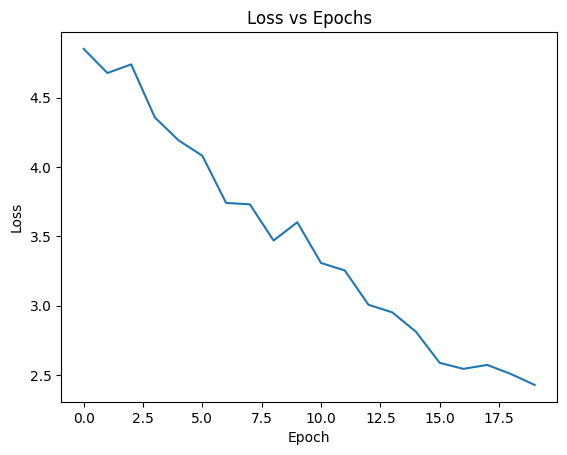

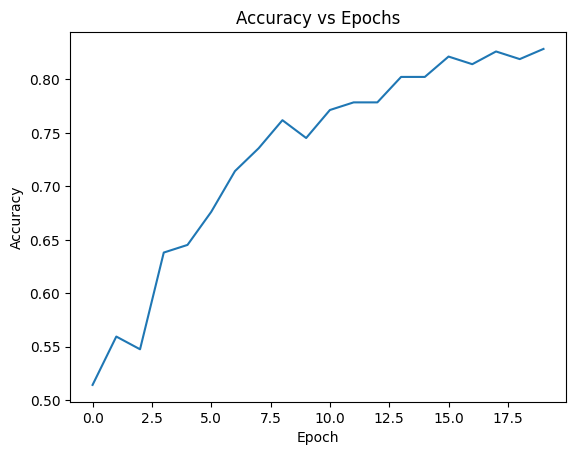

In [17]:
plt.figure(); plt.plot(train_losses); plt.title("Loss vs Epochs"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.show()
plt.figure(); plt.plot(train_accs);   plt.title("Accuracy vs Epochs"); plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.show()

In [18]:
DISASTER_KEYWORDS = [
    "earthquake", "flood", "wildfire", "cyclone", "hurricane", "storm",
    "landslide", "disaster", "damage", "evacuation", "trapped", "rescue",
    "emergency", "dead", "injured", "tsunami", "tornado", "fire", "collapse"
]
 
def predict_label(text, model, word2idx, device):
    """Returns dict with tweet_label and prediction (JSON-ready)."""
    model.eval()
 
    tokens = word_tokenize(clean_text(text))
    seq    = [word2idx.get(w, 0) for w in tokens][:MAX_LEN]
    seq   += [0] * (MAX_LEN - len(seq))
 
    text_tensor = torch.tensor([seq], dtype=torch.long).to(device)
    dummy_img   = torch.zeros((1, 3, IMG_SIZE, IMG_SIZE)).to(device)
 
    with torch.no_grad():
        output     = model(text_tensor, dummy_img)
        prob       = torch.softmax(output, dim=1)
        pred       = torch.argmax(prob, dim=1).item()
        confidence = round(prob.max().item(), 3)
 
    # Keyword override — helps when model is uncertain
    keyword_hit = any(kw in text.lower() for kw in DISASTER_KEYWORDS)
    if pred == 0 and keyword_hit and prob[0][0].item() < 0.70:
        pred = 1
 
    label = "informative" if pred == 1 else "not_informative"
    return {
        "tweet_label": text[:80],        # first 80 chars as label
        "prediction":  label,
        "confidence":  confidence
    }

In [19]:
def fetch_gdelt():
    url = (
        "https://api.gdeltproject.org/api/v2/doc/doc"
        "?query=earthquake+OR+flood+OR+wildfire+OR+cyclone"
        "&mode=artlist&maxrecords=10&format=json"
    )
    try:
        r = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}, timeout=30)
        if not r.text.strip():
            raise ValueError("Empty response")
        data     = r.json()
        articles = data.get("articles", [])
        texts    = [a.get("title", "").strip() for a in articles if a.get("title", "").strip()]
        if texts:
            print(f"✅ GDELT: fetched {len(texts)} articles")
            return texts
        raise ValueError("No articles")
    except Exception as e:
        print(f"⚠️  GDELT failed ({e}), using fallback data")
        return [
            "Earthquake destroys buildings in Turkey",
            "Flood displaces thousands in India",
            "Wildfire spreads rapidly in California",
            "Cyclone approaching coastal regions",
            "Heavy rainfall triggers landslides",
            "Enjoyed a nice cup of coffee today",
            "Government announces new policy reforms",
            "Scientists discover new planet in solar system",
        ]

In [20]:
gdelt_texts = fetch_gdelt()
 
posts = []
for i, text in enumerate(gdelt_texts):
    result = predict_label(text, model, word2idx, device)
    posts.append({"id": f"t{i+1}", **result})
 
output_json = {"source": "GDELT", "total": len(posts), "posts": posts}
 
print("\n🌍 REAL-TIME DISASTER ANALYSIS (JSON OUTPUT)\n")
print(json.dumps(output_json, indent=2))
 
# Also write to file
with open("gdelt_predictions.json", "w") as f:
    json.dump(output_json, f, indent=2)
print("\n✅ Saved to gdelt_predictions.json")

⚠️  GDELT failed (Expecting value: line 1 column 1 (char 0)), using fallback data

🌍 REAL-TIME DISASTER ANALYSIS (JSON OUTPUT)

{
  "source": "GDELT",
  "total": 8,
  "posts": [
    {
      "id": "t1",
      "tweet_label": "Earthquake destroys buildings in Turkey",
      "prediction": "informative",
      "confidence": 0.566
    },
    {
      "id": "t2",
      "tweet_label": "Flood displaces thousands in India",
      "prediction": "informative",
      "confidence": 0.52
    },
    {
      "id": "t3",
      "tweet_label": "Wildfire spreads rapidly in California",
      "prediction": "informative",
      "confidence": 0.598
    },
    {
      "id": "t4",
      "tweet_label": "Cyclone approaching coastal regions",
      "prediction": "informative",
      "confidence": 0.599
    },
    {
      "id": "t5",
      "tweet_label": "Heavy rainfall triggers landslides",
      "prediction": "informative",
      "confidence": 0.625
    },
    {
      "id": "t6",
      "tweet_label": "Enjoyed a ni

In [21]:
torch.save(model.state_dict(), "model_best.pt")
with open("word2idx.pkl", "wb") as f:
    pickle.dump(word2idx, f)
print("✅ model.pt and word2idx.pkl saved")

✅ model.pt and word2idx.pkl saved
